In [542]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants
from astropy import units
from cached_property import cached_property
%matplotlib inline

In [225]:
def make_example_box(x_cells=3, y_cells=3, pml_width=1, ms=20, figsize=(3,3), dpi=200):
    mesh = np.array(
        np.meshgrid(
            np.arange(x_cells + 1 + 2 * pml_width),
            np.arange(y_cells + 1 + 2 * pml_width),
            indexing="ij",
        )
    )
    # For conceptual clarity...
    Ex_mesh = mesh[:,:-1,:]
    Ey_mesh = mesh[:,:,:-1]
    Hz_mesh = mesh[:,:-1,:-1]
    Ex_coords = Ex_mesh.copy().astype(float)
    Ex_coords[0] += 0.5
    Ey_coords = Ey_mesh.copy().astype(float)
    Ey_coords[1] += 0.5
    Hz_coords = Hz_mesh.copy().astype(float) + 0.5

    H_is_split = (
        (Hz_mesh[0] < pml_width) | 
        (Hz_mesh[0] >= pml_width + x_cells) |
        (Hz_mesh[1] < pml_width) |
        (Hz_mesh[1] >= pml_width + y_cells)
    )
    
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111)
    ax.scatter(*Ex_coords, marker='>', color='k', s=ms)
    ax.scatter(*Ey_coords, marker='^', color='k', s=ms)
    ax.scatter(
        Hz_coords[0][H_is_split],
        Hz_coords[1][H_is_split],
        marker='+', 
        s=ms,
        color='k',
    )
    ax.scatter(
        Hz_coords[0][~H_is_split],
        Hz_coords[1][~H_is_split],
        marker='x',
        s=ms,
        color='k',
    )
    box_lower = 0
    box_upper = y_cells + 2 * pml_width
    box_left = 0
    box_right = x_cells + 2 * pml_width
    pml_lower = pml_width
    pml_upper = pml_width + y_cells
    pml_left = pml_width
    pml_right = pml_width + x_cells

    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_xlim(box_left, box_right)
    ax.set_ylim(box_lower, box_upper)
    ax.axhline(box_lower, 0, 1, color='k')
    ax.axhline(box_upper, 0, 1, color='k')
    ax.axvline(box_left, 0, 1, color='k')
    ax.axvline(box_right, 0, 1, color='k')
    ax.axhline(pml_lower, 0, 1, color='k', ls='--')
    ax.axhline(pml_upper, 0, 1, color='k', ls='--')
    ax.axvline(pml_left, 0, 1, color='k', ls='--')
    ax.axvline(pml_right, 0, 1, color='k', ls='--')
    return fig, ax

The general idea behind the FDTD:
* Use Faraday's Law and the Ampere-Maxwell Law to get time-evolution of E, H.
* In this scheme, E advances according to H, and vice-versa.
* Calculate H evolution for half a time step, then do E for a full, then H for half.
  * This is one leapfrog step.
* The lattice also needs to be constructed carefully; Yee's lattice has the E and H fields mutually offset by half a lattice spacing.
  * Figure out how to implement this in a smart way.

Faraday's Law gives three equations:
  
$$
\begin{align}
    \partial_t H_x &= \frac{1}{\mu}\bigl(\partial_z E_y - \partial_y E_z\bigr) \\
    \partial_t H_y &= \frac{1}{\mu}\bigl(\partial_x E_z - \partial_z E_x\bigr) \\
    \partial_t H_z &= \frac{1}{\mu}\bigl(\partial_x E_y - \partial_y E_z\bigr)
\end{align}
$$
  
So we have the discretized equations:
  
$$
\begin{align}
    H_{x,ijk}^{n+1} &= H_{x,ijk}^n + \frac{\Delta t}{\mu} \biggl( \frac{E_{y,ij(k+1/2)}^n - E_{y,ij(k-1/2)}^n}{\Delta z} - \frac{E_{z,i(j+1/2)k}^n - E_{z,i(j-1/2)k}^n}{\Delta y} \biggr) \\
    H_{y,ijk}^{n+1} &= H_{y,ijk}^n + \frac{\Delta t}{\mu} \biggl( \frac{E_{z,(i+1/2)jk}^n - E_{z,(i-1/2)jk}^n}{\Delta x} - \frac{E_{x,ij(k+1/2)}^n - E_{x,ij(k-1/2)}^n}{\Delta z} \biggr) \\
    H_{z,ijk}^{n+1} &= H_{z,ijk}^n + \frac{\Delta t}{\mu} \biggl( \frac{E_{y,(i+1/2)jk}^n - E_{y,(i-1/2)jk}^n}{\Delta x} - \frac{E_{x,i(j+1/2)k}^n - E_{x,i(j-1/2)k}^n}{\Delta y} \biggr).
\end{align}
$$

Ampere-Maxwell Law gives:
  
$$
\begin{align}
    \partial_t E_x &= -\frac{\sigma}{\varepsilon}E_x + \frac{1}{\varepsilon}\bigl( \partial_y H_z - \partial_z H_y \bigr) \\
    \partial_t E_y &= -\frac{\sigma}{\varepsilon}E_y + \frac{1}{\varepsilon}\bigl( \partial_z H_x - \partial_x H_z \bigr) \\
    \partial_t E_z &= -\frac{\sigma}{\varepsilon}E_z + \frac{1}{\varepsilon}\bigl( \partial_x H_y - \partial_y H_x \bigr).
\end{align}
$$
  
These can be discretized to give:
  
$$
\begin{align}
    E_{x,ijk}^{n+1} &= \biggl(1 - \frac{\sigma\Delta t}{\varepsilon}\biggr) E_{x,ijk}^n + \frac{\Delta t}{\varepsilon} \biggl( \frac{H_{z,i(j+1/2)k}^n - H_{z,i(j-1/2)k}^n}{\Delta y} - \frac{H_{y,ij(k+1/2)}^n - H_{y,ij(k-1/2)}^n}{\Delta z} \biggr) \\
    E_{y,ijk}^{n+1} &= \biggl(1 - \frac{\sigma\Delta t}{\varepsilon}\biggr) E_{y,ijk}^n + \frac{\Delta t}{\varepsilon} \biggl( \frac{H_{x,ij(k+1/2)}^n - H_{x,ij(k-1/2)}^n}{\Delta z} - \frac{H_{z,(i+1/2)jk}^n - H_{z,(i-1/2)jk}^n}{\Delta x} \biggr) \\
    E_{z,ijk}^{n+1} &= \biggl(1 - \frac{\sigma\Delta t}{\varepsilon}\biggr) E_{z,ijk}^n + \frac{\Delta t}{\varepsilon} \biggl( \frac{H_{y,(i+1/2)jk}^n - H_{y,(i-1/2)jk}^n}{\Delta x} - \frac{H_{x,i(j+1/2)k}^n - H_{x,i(j-1/2)k}^n}{\Delta y} \biggr)
\end{align}
$$

For a TE$_z$-polarized wave, we only care about three fields: $E_x, E_y, H_z$. Partial derivatives in the $z$-direction vanish. Taking a uniform grid with resolution of $\delta$ and leapfrogging the advancement of the E/H fields, our equations become:
  
$$
\begin{align}
    H_{z,ij}^{n+1} &= H_{z,ij}^n + \frac{\Delta t}{\mu\delta} \Bigl( E_{y,(i+1/2)j}^{n+1/2} - E_{y,(i-1/2)j}^{n+1/2} - E_{x,i(j+1/2)}^{n+1/2} + E_{x,i(j-1/2)}^{n+1/2} \Bigr) \\
    E_{x,ij}^{n+1} &= \biggl(1 - \frac{\sigma\Delta t}{\varepsilon}\biggr) E_{x,ij}^n + \frac{\Delta t}{\varepsilon\delta} \Bigl( H_{z,i(j+1/2)}^{n+1/2} - H_{z,i(j-1/2)}^{n+1/2} \Bigr) \\
    E_{y,ij}^{n+1} &= \biggl(1 - \frac{\sigma\Delta t}{\varepsilon}\biggr) E_{y,ij}^n + \frac{\Delta t}{\varepsilon\delta} \Bigl( H_{z,(i-1/2)j}^{n+1/2} - H_{z,(i+1/2)j}^{n+1/2} \Bigr)
\end{align}
$$

These are the equations we'll use in the free-space region of the simulation domain. For the PML indexed by $a$, we'll split the $H_z$ field as $H_z = H_{zx} + H_{zy}$ and use Berenger's equations:
  
$$
\begin{align}
    \partial_t E_x &= -\frac{\sigma_{a,y}}{\varepsilon} E_x + \frac{1}{\varepsilon}\partial_y  H_z \\
    \partial_t E_y &= -\frac{\sigma_{a,x}}{\varepsilon} E_y - \frac{1}{\varepsilon}\partial_x H_z \\
    \partial_t H_{zx} &= -\frac{\sigma^*_{a,x}}{\mu} H_{zx} - \frac{1}{\mu} \partial_x E_y \\
    \partial_t H_{zy} &= -\frac{\sigma^*_{a,y}}{\mu} H_{zy} + \frac{1}{\mu} \partial_y E_x
\end{align}
$$

Using the more stable exponential differencing scheme, the discretized equations read:
  
$$
\begin{align}
    E_{x,ij}^{n+1} &= \exp\bigl(-\sigma_{a,y}\Delta t/\varepsilon\bigr) E_{x,ij}^n + \frac{1 - \exp\bigl(-\sigma_{a,y}\Delta t/\varepsilon\bigr)}{\sigma_{a,y}\delta} \Bigl( H_{z,i(j+1/2)}^{n+1/2} - H_{z,i(j-1/2)}^{n+1/2} \Bigr) \\
    E_{y,ij}^{n+1} &= \exp\bigl(-\sigma_{a,x}\Delta t/\varepsilon\bigr) E_{y,ij}^n - \frac{1 - \exp\bigl(-\sigma_{a,x}\Delta t/\varepsilon\bigr)}{\sigma_{a,x}\delta} \Bigl( H_{z,(i+1/2)j}^{n+1/2} - H_{z,(i-1/2)j}^{n+1/2} \Bigr) \\
    H_{zx,ij}^{n+1} &= \exp\bigl(-\sigma^*_{a,x}\Delta t/\mu\bigr) H_{zx,ij}^n - \frac{1 - \exp\bigl(-\sigma^*_{a,x}\Delta t/\mu\bigr)}{\sigma^*_{a,x}\delta} \Bigl( E_{y,(i+1/2)j}^{n+1/2} - E_{y,(i-1/2)j}^{n+1/2} \Bigr) \\
    H_{zy,ij}^{n+1} &= \exp\bigl(-\sigma^*_{a,y}\Delta t/\mu\bigr) H_{zy,ij}^n + \frac{1 - \exp\bigl(-\sigma^*_{a,y}\Delta t/\mu\bigr)}{\sigma^*_{a,y}\delta} \Bigl( E_{x,i(j+1/2)}^{n+1/2} - E_{x,i(j-1/2)}^{n+1/2} \Bigr),
\end{align}
$$
  
where $H_z = H_{zx} + H_{zy}$ in the PML.

These are the governing equations, written so that indices line up with where the field points are actually defined on the Yee lattice using the leapfrog integration scheme.
  
In free space:
  
$$
\begin{align}
    H_{z,(i+1/2)(j+1/2)}^{n+1} &= H_{z,(i+1/2)(j+1/2)}^n + \frac{\Delta t}{\mu\delta} \Bigl( E_{y,(i+1)(j+1/2)}^{n+1/2} - E_{y,i(j+1/2)}^{n+1/2} - E_{x,(i+1/2)(j+1)}^{n+1/2} + E_{x,(i+1/2)j}^{n+1/2} \Bigr) \\
    E_{x,(i+1/2)j}^{n+1/2} &= \biggl( 1 - \frac{\sigma \Delta t}{\varepsilon} \biggr) E_{x,(i+1/2)j}^{n-1/2} + \frac{\Delta t}{\varepsilon\delta} \Bigl( H_{z,(i+1/2)(j+1/2)}^n - H_{z,(i+1/2)(j-1/2)}^n \Bigr) \\
    E_{y,i(j+1/2)}^{n+1/2} &= \biggl( 1 - \frac{\sigma \Delta t}{\varepsilon} \biggr) E_{y,i(j+1/2)}^{n-1/2} - \frac{\Delta t}{\varepsilon\delta} \Bigl( H_{z,(i+1/2)(j+1/2)}^n - H_{z,(i-1/2)(j+1/2)}^n \Bigr)
\end{align}
$$
  
In the PML:
  
$$
\begin{align}
    H_{zx,(i+1/2)(j+1/2)}^{n+1} &= \exp\bigl(-\sigma^*_{x,(i+1/2)}\Delta t/\mu\bigr) H_{zx,(i+1/2)(j+1/2)}^n - \frac{1 - \exp\bigl(-\sigma^*_{x,(i+1/2)}\Delta t/\mu\bigr)}{\sigma^*_{x,(i+1/2)}\delta} \Bigl( E_{y,(i+1)(j+1/2)}^{n+1/2} - E_{y,i(j+1/2)}^{n+1/2} \Bigr) \\
    H_{zy,(i+1/2)(j+1/2)}^{n+1} &= \exp\bigl(-\sigma^*_{y,(j+1/2)}\Delta t/\mu\bigr) H_{zy,(i+1/2)(j+1/2)}^n + \frac{1 - \exp\bigl(-\sigma^*_{y,(j+1/2)}\Delta t/\mu\bigr)}{\sigma^*_{y,(j+1/2)}\delta} \Bigl( E_{x,(i+1/2)(j+1)}^{n+1/2} - E_{x,(i+1/2)j}^{n+1/2} \Bigr) \\
    E_{x,(i+1/2)j}^{n+1/2} &= \exp\bigl(-\sigma_{y,j}\Delta t/\varepsilon\bigr) E_{x,(i+1/2)j}^{n-1/2} + \frac{1 - \exp\bigl(-\sigma_{y,j}\Delta t/\varepsilon\bigr)}{\sigma_{y,j}\delta} \Bigl( H_{z,(i+1/2)(j+1/2)}^n - H_{z,(i+1/2)(j-1/2)}^n \Bigr) \\
    E_{y,i(j+1/2)}^{n+1/2} &= \exp\bigl(-\sigma_{x,i}\Delta t/\varepsilon\bigr) E_{y,i(j+1/2)}^{n-1/2} - \frac{1 - \exp\bigl(-\sigma_{x,i}\Delta t/\varepsilon\bigr)}{\sigma_{x,i}\delta} \Bigl( H_{z,(i+1/2)(j+1/2)}^n - H_{z,(i-1/2)(j+1/2)}^n\Bigr)
\end{align}
$$

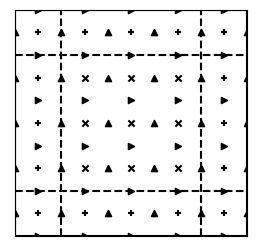

In [227]:
fig, ax = make_example_box(dpi=100)

In [562]:
x = np.arange(25).reshape(5,5)
x[::2,1::2].shape

(3, 2)

In [646]:
sim.relative_permittivity.shape

(223, 223)

In [647]:
class Simulator:
    def __init__(
        self,
        x_cells,
        y_cells,
        pml_width,
        spatial_resolution=units.cm.to("m"),
        courant_number=1/np.sqrt(2),
        Ntimes=100,
        relative_permittivity=1,
        relative_permeability=1,
        pml_conductivity_scale=4.0,
        pml_scaling_index=2,
    ):
        """
        Create a class for managing a FDTD simulation for TE_z-polarized fields.
        
        Parameters
        ----------
        x_cells: int
            Number of cells along the x-direction in the simulation region.
        y_cells: int
            Number of cells along the y-direction in the simulation region.
        pml_width: int
            Number of cells in the PML absorbing boundary.
        spatial_resolution: float
            Physical length of one side of a cell in units of meters. Since this
            is built with the intention of doing RF simulations, the default size
            scale is 1 centimeter.
        courant_number: float, optional
            Courant number defining relative scale of the spatial and temporal
            resolutions. Default based on time for light to cross a cell diagonally.
        Ntimes: int, optional
            Number of time steps to use in the simulation. Can be modified when
            calling the ``simulate`` method.
        relative_permittivity: float or ndarray of float, optional
            Relative permittivity of the space (appropriate for linear media).
            If an array is provided, then it must have shape ``(2 * x_cells + 1,
            2 * y_cells + 1)`` or ``(2 * (x_cells + 2 * pml_width) + 1,
            2 * (y_cells + 2 * pml_width) + 1)``. The first case covers the entirety
            of the non-absorbing region, while the second case covers the entirety
            of the simulation domain. Twice as many samples as grid points are needed
            in order to specify the relative permittivity at every half-step, in
            order to account for the electric fields being defined on a staggered grid.
            Default is to use free space everywhere.
        relative_permeability: float or ndarray of float, optional
            Relative permeability of the space (appropriate for linear media).
            If an array is provided, then it must have shape ``(x_cells - 1,
            y_cells - 1)`` or ``(x_cells - 1 + 2 * pml_width,
            y_cells - 1 + 2 * pml_width)``. The first case covers the entirety of the
            non-absorbing region, while the second case covers the entirety of the
            simulation domain. Free space everywhere is used by default.
        pml_conductivity_scale: float, optional
            Value of the PML conductivity at its outer edge. Default value
            based on the value used in Berenger (1994).
        pml_scaling_index: float, optional
            Power-law index for PML conductivity scaling. Default is to use
            parabolic scaling.
            
        Attributes
        ----------
        mesh: ndarray of int
            Mesh specifying indices for each point on the grid. None of the
            physical fields exist on the entirety of the mesh.
        Ex_mesh, Ey_mesh, Hzx_mesh, Hzy_mesh: ndarray of int
            Mesh used for each of the fields used in the simulation. If the
            ``mesh`` attribute has shape (M,N), then the field meshes have the
            following shapes:
                Ex_mesh: (M-1,N)
                Ey_mesh: (M,N-1)
                Hzx_mesh, Hzy_mesh: (M-1,N-1)
        Ex_coords, Ey_coords, Hz_coords: ndarray of float
            Coordinate grids for each of the fields according to the Yee lattice.
            The fields are aligned or offset from the gridlines as follows:
                Ex_coords: x-offset, y-aligned
                Ey_coords: x-aligned, y-offset
                Hz_coords: x-offset, y-offset
        pml_conductivity: ndarray of float
            Conductivity in the PML, evaluated at each cell edge and center, except
            the outermost cell edge. Has shape (``2 * pml_width``,). Each value is
            the average over a cell centered on the point. The average is calculated
            through a numerical integral of the conductivity profile, assuming a
            power-law scaling increasing from zero at the inner edge to
            ``pml_conductivity_scale`` at the outer edge.
        magnetic_loss: ndarray of float
            Magnetic loss in the PML corresponding to free-space in the non-absorbing
            region.
        prefactors: float or ndarray of float
            Various prefactors are calculated for each region once per class instance.
            These prefactors are cached to enhance performance. The prefactors that
            are precomputed are named with values calculated as follows:
                Ex_prefac, Ey_prefac:
                    Prefactors on the electric field terms. These are unity in the
                    non-absorbing regions, and exponentially decaying in the PMLs.
                Hzx_prefac, Hzy_prefac:
                    Prefactors on the magnetic field terms. These are unity in the
                    non-absorbing regions, and exponentially decaying in the PMLs.
                curlEx_prefac, curlEy_prefac:
                    Prefactors on the electric field curls. These are determined by
                    the Courant number, free-space impedance, and relative permeability.
                    The (x,y) labels signify which magnetic field component they
                    correspond to (Hzx or Hzy).
                curlHx_prefac, curlHy_prefac:
                    Prefactors on the magnetic field curls, with (x,y) labels signifying
                    which electric field component they correspond to. These are
                    determined by the Courant number, free-space impedance, and relative
                    permittivity.
            Each prefactor array has the same shape as the corresponding field to
            be updated using the prefactor (and relevant terms).
        classifiers: dict
            Dictionary used to make code for identifying which region each
            point resides in more readable. Keys are:
                left_pml
                right_pml
                lower_pml
                upper_pml
                left_edge
                right_edge
                lower_edge
                upper_edge
            The values are all numpy boolean arrays and so only marginally
            contribute to memory consumption.
        """
        # Grid initialization parameters.
        self.x_cells = x_cells
        self.y_cells = y_cells
        self.pml_width = pml_width
        
        # Physical parameters.
        self.relative_permittivity = np.atleast_2d(relative_permittivity)
        self._reshape_permittivity()  # Cast it to the correct shape.
        self.relative_permeability = np.atleast_2d(relative_permeability)
        self._reshape_permeability()  # Cast it to the correct shape.
        self.free_impedance = np.sqrt(constants.mu0.si.value / constants.eps0.si.value)
        self.pml_conductivity_scale = pml_conductivity_scale
        self.pml_scaling_index = pml_scaling_index
        
        # Integration parameters.
        self.courant_number = courant_number
        self.spatial_resolution = spatial_resolution
        self.Ntimes = Ntimes
        
        # Initialize the fields. Use split H everywhere for simplicity.
        self.Ex = np.zeros((Ntimes,) + self.Ex_mesh[0].shape, dtype=np.float)
        self.Ey = np.zeros((Ntimes,) + self.Ey_mesh[0].shape, dtype=np.float)
        self.Hzx = np.zeros((Ntimes,) + self.Hz_mesh[0].shape, dtype=np.float)
        self.Hzy = self.Hzx.copy()

        # Information dictionary for when simulation is performed.
        self.info = {}
        
    
    @cached_property
    def mesh(self):
        return np.array(
            np.meshgrid(
                np.arange(self.x_cells + 2 * self.pml_width + 1),
                np.arange(self.y_cells + 2 * self.pml_width + 1),
                indexing="ij",
            )
        )
        
        
    @cached_property
    def Ex_mesh(self):
        return self.mesh[:,:-1,:]
    
    
    @cached_property
    def Ey_mesh(self):
        return self.mesh[:,:,:-1]
    
    
    @cached_property
    def Hz_mesh(self):
        return self.mesh[:,:-1,:-1]
        
        
    @cached_property
    def Ex_coords(self):
        Ex_coords = self.Ex_mesh.copy().astype(float)
        Ex_coords[0] += 0.5
        return Ex_coords
        
    
    @cached_property
    def Ey_coords(self):
        Ey_coords = self.Ey_mesh.copy().astype(float)
        Ey_coords[1] += 0.5
        return Ey_coords
        
        
    @cached_property
    def Hz_coords(self):
        return self.Hzx_mesh.copy().astype(float) + 0.5
        
    
    @cached_property
    def Ex_prefac(self):
        # Exponential decay in upper/lower PML, unity otherwise.
        upper_pml = self.classifiers["upper_pml"][:-1,:]
        lower_pml = self.classifiers["lower_pml"][:-1,:]
        upper_pml_edge = self.Ex_mesh[1,upper_pml].min()
        scale_factor = 1 / self.relative_permittivity[1::2,::2]
        scale_factor *= self.spatial_resolution * self.courant_number * self.free_impedance
        conductivity = self.pml_conductivity[::2]
        prefactors = np.zeros(self.Ex_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(1, prefactors.shape[1]-1):
                if upper_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -conductivity[j-upper_pml_edge] * scale_factor[i,j]
                    )
                elif lower_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -conductivity[::-1][j] * scale_factor[i,j]
                    )
                else:
                    prefactors[i,j] = 1
        return prefactors
    
    
    @cached_property
    def Ey_prefac(self):
        # Exponential decay in left/right PML, unity otherwise.
        left_pml = self.classifiers["left_pml"][:,:-1]
        right_pml = self.classifiers["right_pml"][:,:-1]
        right_pml_edge = self.Ey_mesh[0,right_pml].min()
        scale_factor = 1 / self.relative_permittivity[::2,1::2]
        scale_factor *= self.spatial_resolution * self.courant_number * self.free_impedance
        conductivity = self.pml_conductivity[::2]
        prefactors = np.zeros(self.Ey_mesh[0].shape, dtype=np.float)
        for i in range(1, prefactors.shape[0] - 1):
            for j in range(prefactors.shape[1]):
                if left_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -conductivity[::-1][i] * scale_factor[i,j]
                    )
                elif right_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -conductivity[i-right_pml_edge] * scale_factor[i,j]
                    )
                else:
                    prefactors[i,j] = 1
        return prefactors
    
    
    @cached_property
    def Hzx_prefac(self):
        # Exponential decay in left/right PML, unity otherwise
        left_pml = self.classifiers["left_pml"][:-1,:-1]
        right_pml = self.classifiers["right_pml"][:-1,:-1]
        right_pml_edge = self.Hz_mesh[0,right_pml].min()
        # Impedance match and scale by the time step.
        scale_factor = 1 / self.relative_permittivity[1::2,1::2]
        scale_factor *= self.courant_number * (
            self.spatial_resolution / self.free_impedance
        )
        prefactors = np.zeros(self.Hz_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(prefactors.shape[1]):
                if left_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -self.magnetic_loss[::-1][i] * scale_factor[i,j]
                    )
                elif right_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -self.magnetic_loss[i-right_pml_edge] * scale_factor[i,j]
                    )
                else:
                    prefactors[i,j] = 1
        return prefactors
    
    
    @cached_property
    def Hzy_prefac(self):
        # Exponential decay in lower/upper PML, unity otherwise
        lower_pml = self.classifiers["lower_pml"][:-1,:-1]
        upper_pml = self.classifiers["upper_pml"][:-1,:-1]
        upper_pml_edge = self.Hz_mesh[1,upper_pml].min()
        # Impedance match and scale by the time step.
        scale_factor = 1 / self.relative_permittivity[1::2,1::2]
        scale_factor *= self.courant_number * (
            self.spatial_resolution / self.free_impedance
        )
        prefactors = np.zeros(self.Hz_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(prefactors.shape[1]):
                if lower_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -self.magnetic_loss[::-1][j] * scale_factor[i,j]
                    )
                elif upper_pml[i,j]:
                    prefactors[i,j] = np.exp(
                        -self.magnetic_loss[j-upper_pml_edge] * scale_factor[i,j]
                    )
                else:
                    prefactors[i,j] = 1
        return prefactors
    
    
    @cached_property
    def curlHx_prefac(self):
        # Ex has x-offset, y-aligned. Modified in upper/lower PMLs.
        upper_pml = self.classifiers["upper_pml"][:-1,:]
        lower_pml = self.classifiers["lower_pml"][:-1,:]
        upper_pml_edge = self.Ex_mesh[1,upper_pml].min()
        conductivity = self.pml_conductivity[::2]  # At cell edges.
        prefactors = np.zeros(self.Ex_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(1, prefactors.shape[1] - 1):
                if lower_pml[i,j+1]:
                    prefactors[i,j] = (1 - self.Ex_prefac[i,j]) / (
                        conductivity[::-1][j] * self.spatial_resolution
                    )
                elif upper_pml[i,j-1]:
                    prefactors[i,j] = (1 - self.Ex_prefac[i,j]) / (
                        conductivity[j-upper_pml_edge] * self.spatial_resolution
                    )
                else:
                    prefactors[i,j] = self.courant_number * self.free_impedance / (
                        self.relative_permittivity[1::2,::2][i,j]
                    )
        return prefactors
        
    
    @cached_property
    def curlHy_prefac(self):
        # Ey has x-aligned, y-offset. Modified in left/right PMLs.
        left_pml = self.classifiers["left_pml"][:,:-1]
        right_pml = self.classifiers["right_pml"][:,:-1]
        right_pml_edge = self.Ey_mesh[0,right_pml].min()
        conductivity = self.pml_conductivity[::2]  # At cell edges.
        prefactors = np.zeros(self.Ey_mesh[0].shape, dtype=np.float)
        for i in range(1, prefactors.shape[0] - 1):
            for j in range(prefactors.shape[1]):
                if left_pml[i+1,j]:
                    prefactors[i,j] = (1 - self.Ey_prefac[i,j]) / (
                        conductivity[::-1][i] * self.spatial_resolution
                    )
                elif right_pml[i-1,j]:
                    prefactors[i,j] = (1 - self.Ey_prefac[i,j]) / (
                        conductivity[i-right_pml_edge] * self.spatial_resolution
                    )
                else:
                    prefactors[i,j] = self.courant_number * self.free_impedance / (
                        self.relative_permittivity[::2,1::2][i,j]
                    )
        return prefactors
        
    
    @cached_property
    def curlEx_prefac(self):
        # Corresponds to Hzx updates. Modified in left/right PMLs.
        left_pml = self.classifiers["left_pml"][:-1,:-1]
        right_pml = self.classifiers["right_pml"][:-1,:-1]
        right_pml_edge = self.Hz_mesh[0,right_pml].min()
        # Impedance match in PML and scale by spatial resolution.
        scale_factor = self.relative_permittivity[1::2,1::2] / (
            self.relative_permeability * self.spatial_resolution
        )
        print(scale_factor.shape)
        prefactors = np.zeros(self.Hz_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(prefactors.shape[1]):
                if left_pml[i,j]:
                    prefactors[i,j] = (1 - self.Hzx_prefac[i,j]) * (
                        scale_factor[i,j] / self.magnetic_loss[::-1][i]
                    )
                elif right_pml[i,j]:
                    prefactors[i,j] = (1 - self.Hzx_prefac[i,j]) * (
                        scale_factor[i,j] / self.magnetic_loss[i-right_pml_edge]
                    )
                else:
                    prefactors[i,j] = self.courant_number / (
                        self.free_impedance * self.relative_permeability[i,j]
                    )
        return prefactors
        
    
    @cached_property
    def curlEy_prefac(self):
        # Corresponds to Hzy updates. Modified in upper/lower PMLs.
        upper_pml = self.classifiers["upper_pml"][:-1,:-1]
        lower_pml = self.classifiers["lower_pml"][:-1,:-1]
        upper_pml_edge = self.Hz_mesh[1,upper_pml].min()
        # Impedance match in the PML and scale by spatial resolution.
        scale_factor = self.relative_permittivity[1::2,1::2] / (
            self.relative_permeability * self.spatial_resolution
        )
        prefactors = np.zeros(self.Hz_mesh[0].shape, dtype=np.float)
        for i in range(prefactors.shape[0]):
            for j in range(prefactors.shape[1]):
                if lower_pml[i,j]:
                    prefactors[i,j] = (1 - self.Hzy_prefac[i,j]) * (
                        scale_factor[i,j] / self.magnetic_loss[::-1][j]
                    )
                elif upper_pml[i,j]:
                    prefactors[i,j] = (1 - self.Hzy_prefac[i,j]) * (
                        scale_factor[i,j] / self.magnetic_loss[j-upper_pml_edge]
                    )
                else:
                    prefactors[i,j] = self.courant_number / (
                        self.free_impedance * self.relative_permeability[i,j]
                    )
        return prefactors
    
    
    def _reshape_permittivity(self):
        nonabc_shape = (2 * self.x_cells + 1, 2 * self.y_cells + 1)
        full_shape = (
            2 * (self.x_cells + 2 * pml_width) + 1,
            2 * (self.y_cells + 2 * pml_width) + 1,
        )
        self._reshape_field("relative_permittivity", nonabc_shape, full_shape)
            
            
    def _reshape_permeability(self):
        nonabc_shape = (self.x_cells - 1, self.y_cells - 1)
        full_shape = self.Hz_mesh[0].shape
        self._reshape_field("relative_permeability", nonabc_shape, full_shape)

    
    def _reshape_field(self, field_name, nonabc_shape, full_shape):
        current_shape = getattr(self, field_name).shape
        if current_shape == full_shape:
            return
        if current_shape == (1,1):
            setattr(
                self,
                field_name,
                np.ones(full_shape) * getattr(self, field_name)
            )
        elif current_shape == nonabc_shape:
            self._extend_field(field_name, full_shape)
        else:
            raise ValueError(
                f"{field_name} must either be a scalar or"
                f"have shape {nonabc_shape} or {full_shape}. The provided"
                f"array shape is {current_shape}. See class documentation"
                "for further details."
            )

    
    def _extend_field(self, field_name, full_shape):
        """Utility function for extending fields to fill a space."""
        field = getattr(self, field_name)
        shape = field.shape
        x_repeats = (full_shape[0] - shape[0]) // 2
        y_repeats = (full_shape[1] - shape[1]) // 2
        field_top = field[0].reshape(1,-1)
        field_bottom = field[-1].reshape(1,-1)
        field = np.concatenate(
            (
                np.repeat(field_top, y_repeats, axis=0),
                field,
                np.repeat(field_bottom, y_repeats, axis=0),
            ),
            axis=0,
        )
        field_left = field[:,0].reshape(-1,1)
        field_right = field[:,-1].reshape(-1,1)
        field = np.concatenate(
            (
                np.repeat(field_left, x_repeats, axis=1),
                field,
                np.repeat(field_right, x_repeats, axis=1),
            ),
            axis=1,
        )
        setattr(self, field_name, field)
        
        
    @cached_property
    def classifiers(self):
        # Pre-calculate some stuff for readability.
        left_pml_boundary = self.pml_width
        right_pml_boundary = self.x_cells + self.pml_width
        lower_pml_boundary = self.pml_width
        upper_pml_boundary = self.y_cells + self.pml_width
        right_boundary = self.x_cells + 2 * self.pml_width
        upper_boundary = self.y_cells + 2 * self.pml_width
        
        # Actually make the classifications.
        classifiers = {}
        classifiers["left_pml"] = (self.mesh[0] < left_pml_boundary)
        classifiers["right_pml"] = (self.mesh[0] >= right_pml_boundary)
        classifiers["lower_pml"] = (self.mesh[1] < lower_pml_boundary)
        classifiers["upper_pml"] = (self.mesh[1] >= upper_pml_boundary)
        classifiers["left_edge"] = (self.mesh[0] == 0)
        classifiers["right_edge"] = (self.mesh[0] == right_boundary)
        classifiers["lower_edge"] = (self.mesh[1] == 0)
        classifiers["upper_edge"] = (self.mesh[1] == upper_boundary)
        return classifiers
    
    
    @cached_property
    def pml_conductivity(self):
        """Average conductivity over each cell for power-law conductivity.
        
        Notes
        -----
        The electric field calculations use these. The x-component uses the
        y-conductivity and vice-versa. The E-field couplings are at the same
        points the E-fields are defined at; the H-field couplings are at the
        same points the H-fields are defined at. So we need to calculate these
        values at the cell edges and the cell centers. Since this simulation
        has each PML conductivity functionally identical, we really only need
        to calculate it for one of the PMLs.
        """
        coordinates = np.arange(2 * self.pml_width + 1).astype(float) / 2
        pml_conductivity = np.zeros(2 * self.pml_width, dtype=float)
        def conductivity(x):
            return self.pml_conductivity_scale * (
                x / self.pml_width
            ) ** self.pml_scaling_index
        
        for i in range(1, 2 * self.pml_width):
            pml_conductivity[i] = self._simp_int(
                conductivity, coordinates[i-1], coordinates[i+1]
            )
        return pml_conductivity    
        
    
    @cached_property
    def magnetic_loss(self):
        # We only ever need this at the cell midpoints.
        return self.pml_conductivity[1::2] * self.free_impedance ** 2
    
        
    @staticmethod
    def _simp_int(func, x1, x2, Npts=21):
        """Numerically integrate a function from x1 to x2."""
        scale_factors = np.ones(Npts, dtype=float)
        scale_factors[1::2] = 4
        scale_factors[2:-1:2] = 2
        scale_factors /= 3
        xvals = np.linspace(x1, x2, Npts)
        dx = np.mean(np.diff(xvals))
        return func(np.linspace(x1, x2, Npts)) @ scale_factors * dx
    
    
    def _initialize_fields(self, Ntimes):
        self.Ntimes = Ntimes
        self.Ex = np.zeros((Ntimes,) + self.Ex_mesh[0].shape, dtype=float)
        self.Ey = np.zeros((Ntimes,) + self.Ey_mesh[0].shape, dtype=float)
        self.Hzx = np.zeros((Ntimes,) + self.Hzx_mesh[0].shape, dtype=float)
        self.Hzy = np.zeros((Ntimes,) + self.Hzy_mesh[0].shape, dtype=float)
        
        
    def _advance_Hzx(self, Hzx, Ey_right, Ey_left, H_prefac, curlE_prefac):
        """Advance Hzx at a point by one timestep."""
        return H_prefac * Hzx - curlE_prefac * (Ey_right - Ey_left)

    
    def _advance_Hzy(self, Hzy, Ex_above, Ex_below, H_prefac, curlE_prefac):
        """Advance Hzy at a point by one timestep."""
        return H_prefac * Hzy + curlE_prefac * (Ex_above - Ex_below)

    
    def _advance_Hz(self, Hz, Ex_above, Ex_below, Ey_right, Ey_left, curlE_prefac):
        """Advance Hz at a point by one timestep."""
        curlE = Ey_right - Ey_left - (Ex_above - Ex_below)
        return Hz + curlE_prefac * curlE

    
    def _advance_Ex(self, Ex, Hz_above, Hz_below, curlH_prefac, E_prefac):
        """Advance Ex at a point by one timestep."""
        return E_prefac * Ex + curlH_prefac * (Hz_above - Hz_below)

    
    def _advance_Ey(self, Ey, Hz_right, Hz_left, curlH_prefac, E_prefac):
        """Advance Ey at a point by one timestep."""
        return E_prefac * Ey - curlH_prefac * (Hz_right - Hz_left)

    
    def advance_fields(self, step, source_func, source_loc, **source_params):
        for i in range(self.x_cells + 2 * self.pml_width + 1):
            in_left_pml = self.classifiers["left_pml"][i,0]
            in_right_pml = self.classifiers["right_pml"][i,0]
            at_right_edge = self.classifiers["right_edge"][i,0]
            at_left_edge = self.classifiers["left_edge"][i,0]
            for j in range(self.y_cells + 2 * self.pml_width + 1):
                in_lower_pml = self.classifiers["lower_pml"][0,j]
                in_upper_pml = self.classifiers["upper_pml"][0,j]
                at_upper_edge = self.classifiers["upper_edge"][0,j]
                at_lower_edge = self.classifiers["lower_edge"][0,j]
                
                # There's nothing to do at these edges.
                if at_upper_edge or at_right_edge:
                    continue
                
                # Advance the magnetic field. Just take the H-field to always be split.
                dHzx = self._advance_Hzx(
                    self.Hzx[step-1,i,j],
                    self.Ey[step-1,i+1,j],
                    self.Ey[step-1,i,j],
                    self.Hzx_prefac[i,j],
                    self.curlEx_prefac[i,j],
                )
                dHzy = self._advance_Hzy(
                    self.Hzy[step-1,i,j],
                    self.Ex[step-1,i,j+1],
                    self.Ex[step-1,i,j],
                    self.Hzy_prefac[i,j],
                    self.curlEy_prefac[i,j],
                )
                self.Hzx[step,i,j] = self.Hzx[step-1,i,j] + dHzx
                self.Hzy[step,i,j] = self.Hzy[step-1,i,j] + dHzy
                
                # The source should only be applied to the magnetic field,
                # since we're doing a TE_z-polarization simulation.
                # FIXME: figure out the right way to do this...
                self.apply_source(source_func, source_loc, step, **source_params)
                
                # Advance the electric field.
                # If we're at the lower edge, we can't calculate the curl for Ex.
                if not at_lower_edge:
                    dEx = self._advance_Ex(
                        self.Ex[step-1,i,j],
                        self.Hzx[step,i,j] + self.Hzy[step,i,j],
                        self.Hzx[step,i,j-1] + self.Hzy[step,i,j-1],
                        self.curlHx_prefac[i,j],
                        self.Ex_prefac[i,j],
                    )
                    self.Ex[step,i,j] = self.Ex[step-1,i,j] + dEx
                    
                # If we're at the left edge, we can't calculate the curl for Ey.
                if not at_left_edge:
                    dEy = self._advance_Ey(
                        self.Ey[step-1,i,j],
                        self.Hzx[step,i,j] + self.Hzy[step,i,j],
                        self.Hzx[step,i-1,j] + self.Hzy[step,i-1,j],
                        self.curlHy_prefac[i,j],
                        self.Ey_prefac[i,j],
                    )
                    self.Ey[step,i,j] = self.Ey[step-1,i,j] + dEy
    
    
    def apply_source(self, source_func, source_loc, step, **source_params):
        time = step * self.time_res
        Ex, Ey, Hz = source_func(time, self.time_res, **source_params)
        self.Ex[step][source_loc] += Ex
        self.Ey[step][source_loc] += Ey
        self.Hzx[step][source_loc] += 0.5 * Hz
        self.Hzy[step][source_loc] += 0.5 * Hz
        
        
    def simulate(
        self, Ntimes=500, source_func="pulse", source_loc=None, source_params=None,
    ):
        """Run the FDTD simulation.
        
        Parameters
        ----------
        Ntimes: int
            Number of time steps in simulation.
        source_func: callable or str
            Function for applying a source term. Must have signature:
                source_func(time, dt, **source_params)
            Must return Ex, Ey, Hz. Currently only supports time-dependent source.
        source_loc: tuple of slice parameters
            Specifies the location of the source.
        source_params: dict
            Parameters to supply source_func
        """
        if any(param is None for param in (source_func, source_loc)):
            print("No source provided. Returning.")
            return
        source_params = source_params or {}
        self._initialize_fields(Ntimes)
        self.apply_source(
            source_func, source_loc, 0, **source_params
        )
        
        # Integrate in time.
        for step in range(1, Ntimes):
            if step % 10 == 0:
                print(f"{100 * step / Ntimes}% done.")
            self.advance_fields(step)
        
        # Fill out the information dictionary.
        if isinstance(source_func, str):
            source_type = source_func
        else:
            source_type = source_func.__name__
        source_inds = self.mesh[(slice(None),) + source_loc]
        self.info["source_type"] = source_type
        self.info["source_inds"] = source_inds
        self.info["source_pos"] = source_inds * self.spatial_res

        
    def write(self, save_path):
        """Write simulation results to disk."""
        # Cast E and H to the same grids/times; might need to do
        # better than linear interpolation, though.
        Ex = 0.5 * (self.Ex[:,:,1:] + self.Ex[:,:,:-1])[:-1]
        Ey = 0.5 * (self.Ey[:,1:,:] + self.Ey[:,:-1,:])[:-1]
        Hz = self.Hzx + self.Hzy
        Hz = 0.5 * (Hz[1:] + Hz[:-1])
        np.savez(
            save_path,
            x_cells=self.x_cells,
            y_cells=self.y_cells,
            pml_width=self.pml_width,
            delta=self.spatial_res,
            dt=self.time_res,
            courant_number=self.courant_number,
            Ntimes=self.Ntimes-1,
            c=self.c,
            eps=self.permittivity,
            mu=self.permeability,
            free_cond=self.free_conductivity,
            pml_cond_scale=self.pml_conductivity_scale,
            pml_scaling=self.pml_scaling,
            Ex=Ex,
            Ey=Ey,
            Hz=Hz,
            **self.info
        )

In [616]:
def directed_oscillating_source(
    time, dt, freq=1420*units.MHz.to("Hz"), H_amp=1, angle=0, t_cut=2e-12
):
    if time > t_cut:
        return 0, 0, 0
    Hz = H_amp * np.sin(2 * np.pi * time * freq)
    E_amp = H_amp * constants.mu0.si.value / constants.c.si.value
    E = E_amp * np.sin(2 * np.pi * (time + 0.5 * dt) * freq)
    Ex = E * np.sin(angle)
    Ey = E * np.cos(angle)
    return Ex, Ey, Hz

In [617]:
def source(time, dt, freq=1420*units.MHz.to("Hz"), E_amp=1):
    Ex = E_amp * np.sin(2 * np.pi * (time + 0.5 * dt) * freq)
    return Ex, 0, 0

In [618]:
def pulse(
    time, dt, timescale=2*units.ps.to('s'), H_amp=1,
):
    Hz = H_amp * np.exp(-0.5 * (time / timescale) ** 2)
    E_amp = H_amp * constants.mu0.si.value / constants.c.si.value
    E = E_amp * np.exp(-0.5 * ((time + 0.5 * dt) / timescale) ** 2)
    return E / np.sqrt(2), E / np.sqrt(2), Hz

In [648]:
sim = Simulator(
    x_cells=101,
    y_cells=101,
    pml_width=5,
    spatial_resolution=1*units.cm.to("m"),
    courant_number=1,
)

In [539]:
sim.Ex_coords[:,1,2]

array([0.015, 0.02 ])

In [540]:
sim.Ey_coords[:,1,2]

array([0.01 , 0.025])

In [541]:
sim.Hzx_coords[:,1,2]

array([0.015, 0.025])

In [524]:
x_mid = (sim.x_cells + 2 * sim.pml_width + 1) // 2
y_mid = (sim.y_cells + 2 * sim.pml_width + 1) // 2
#source_loc = (slice(x_mid - 2, x_mid + 2), slice(y_mid - 2, y_mid + 2))
source_loc = (x_mid, y_mid)
sim.simulate(Ntimes=50, source_func=source, source_loc=source_loc)

20.0% done.
40.0% done.
60.0% done.
80.0% done.


In [528]:
sim.free_curlE_prefac * (sim.Ex[0,x_mid,y_mid] - sim.Ex[0,x_mid,y_mid-1])

0.00039353467410034495

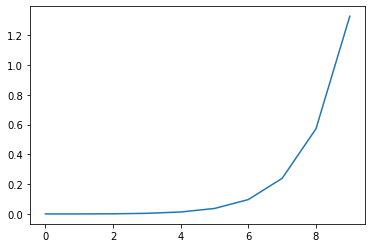

In [525]:
plt.plot(sim.Hzx[:10,x_mid,y_mid])

In [511]:
sim.Hzx[,x_mid,y_mid]

0.0

In [500]:
sim.free_E_prefac

0.9999996232696864

In [501]:
sim.free_curlH_prefac

376.73031366686985

In [502]:
sim.free_curlE_prefac

0.0026544187279930716

In [488]:
sim.c * sim.time_res

1e-06

In [489]:
sim.spatial_res

0.0001

In [484]:
sim.Hzx.max()

552521.1842665994

In [419]:
source_loc = (pml_width + 3, slice(pml_width,-pml_width))
sim.simulate(Ntimes=50, source_func=directed_oscillating_source, source_loc=source_loc)

20.0% done.
40.0% done.
60.0% done.
80.0% done.


In [437]:
# Figure out how to visualize this stuff...
Ex = 0.5 * (sim.Ex[:,:,1:] + sim.Ex[:,:,:-1])[:-1]
Ey = 0.5 * (sim.Ey[:,1:,:] + sim.Ey[:,:-1,:])[:-1]
Hz = sim.Hzx + sim.Hzy
Hz = 0.5 * (Hz[1:] + Hz[:-1])

In [438]:
Sx = Ey * Hz
Sy = - Ex * Hz
intensity = np.sqrt(Sx ** 2 + Sy ** 2)

In [444]:
Ex_pt = Ex[:,x_mid,y_mid]
Ey_pt = Ey[:,x_mid,y_mid]
Hz_pt = Hz[:,x_mid,y_mid]

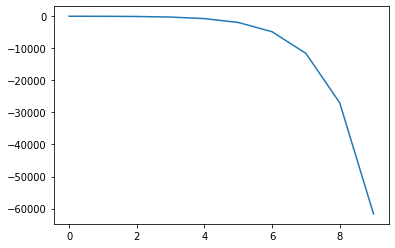

In [448]:
plt.plot(Ex_pt[:10])

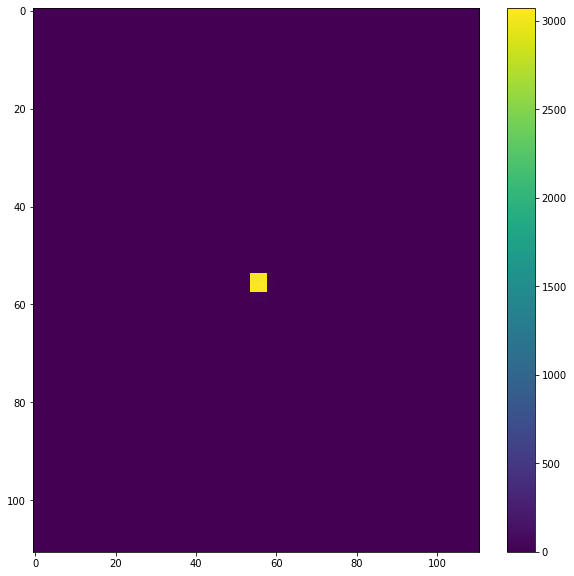

In [440]:
plt.figure(figsize=(10,10))
plt.imshow(Hz[10].T, aspect='auto')#, vmax=10, vmin=0)
plt.colorbar()